In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.stats import hmean
from scipy import stats

In [2]:
plt.style.use("default")

In [3]:
"""
GENERATE THE ABILITY PROFILES
"""
# -------------------------------
# Model Groups and Name Mapping
# -------------------------------

# Define the color intensity for each LLM family from light to dark
gpt_o1_models = [
    ('babbage-002', 0.16),
    ('davinci-002', 0.32),
    ('gpt-35-turbo', 0.48),
    ('gpt4o', 0.64),
    ('o1-mini', 0.80),
    ('o1_re=low', 1.0)
]

llama_models = [
    ('llama3d2-1b', 0.2),
    ('llama3d2-3b', 0.4),
    ('llama3d2-11b', 0.6),
    ('llama3d2-90b', 0.8),
    ('llama3d1-405b', 1.0)
]

ds_r1_models = [
    ('DK-R1-Dist-Qwen-1.5B', 0.25),
    ('DK-R1-Dist-Qwen-7B', 0.50),
    ('DK-R1-Dist-Qwen-14B', 0.75),
    ('DK-R1-Dist-Qwen-32B', 1.0)
]

# Standardise the names
name_mapping = {
    'babbage-002': 'Babbage-002',
    'davinci-002': 'Davinci-002',
    'gpt-35-turbo': 'GPT-3.5-Turbo',
    'gpt4o': 'GPT-4o',
    'o1-mini': 'OpenAI o1-mini',
    'o1_re=low': 'OpenAI o1',
    'llama3d2-1b': 'LLaMA-3.2-1B-Instruct',
    'llama3d2-3b': 'LLaMA-3.2-3B-Instruct',
    'llama3d2-11b': 'LLaMA-3.2-11B-Instruct',
    'llama3d2-90b': 'LLaMA-3.2-90B-Instruct',
    'llama3d1-405b': 'LLaMA-3.1-405B-Instruct',
    'DK-R1-Dist-Qwen-1.5B': 'DK-R1-Dist-Qwen-1.5B',
    'DK-R1-Dist-Qwen-7B': 'DK-R1-Dist-Qwen-7B',
    'DK-R1-Dist-Qwen-14B': 'DK-R1-Dist-Qwen-14B',
    'DK-R1-Dist-Qwen-32B': 'DK-R1-Dist-Qwen-32B'
}

# -------------------------------------------
# Data Augmentation: Sample Weighting with Synthetic Anchor
# -------------------------------------------
def compute_sample_weights_with_anchor(X_feature, y_feature, dup_threshold):
    """
    For the given feature (with values in {1,2,3,4,5}), compute sample weights for each instance
    using real-valued targets instead of duplicating rows.

    For each bin:
      - If the number of instances is >= dup_threshold, the target is set to the maximum eligible count (as a float).
      - Otherwise, the target is computed proportionally so that the bin’s share reflects its original proportion.

    The weight for each sample in a bin is:
         weight = (target as a real number) / (original count in that bin)

    A single synthetic anchor point is then created at level 20 with label 0.
    Its weight is equal to the sum of the targets across levels 1–5.

    Returns:
       X_train: augmented feature array (original points plus anchor)
       y_train: augmented target array (original labels plus 0 for the anchor)
       combined_weights: sample weights for each row
    """
    # Ensure X_feature is 2D.
    if X_feature.ndim == 1:
        X_feature = X_feature.reshape(-1, 1)

    # Count instances per level for levels 1–5.
    levels = [1, 2, 3, 4, 5]
    counts = {level: np.sum(X_feature.flatten() == level) for level in levels}
    total_original = sum(counts.values())

    # Determine eligible bins (count >= dup_threshold)
    eligible_levels = [level for level in levels if counts[level] >= dup_threshold]
    if eligible_levels:
        majority_count = max(counts[level] for level in eligible_levels)
    else:
        majority_count = max(counts.values())

    # Set target for each bin.
    targets = {}
    for level in levels:
        if counts[level] >= dup_threshold:
            targets[level] = float(majority_count)
        else:
            targets[level] = None  # placeholder for ineligible bins.

    # Compute targets for ineligible bins proportionally.
    ineligible_levels = [level for level in levels if targets[level] is None]
    E = sum(targets[level] for level in levels if targets[level] is not None)
    sum_ineligible = sum(counts[level] for level in ineligible_levels)
    if sum_ineligible > 0:
        T = E / (1 - (sum_ineligible / total_original))
    else:
        T = E
    for level in ineligible_levels:
        targets[level] = (counts[level] / total_original) * T

    # Compute sample weights for each instance.
    sample_weights = np.zeros(X_feature.shape[0], dtype=float)
    for level in levels:
        mask = (X_feature.flatten() == level)
        count_level = counts[level]
        if count_level > 0:
            weight_factor = targets[level] / count_level
            sample_weights[mask] = weight_factor

    # Print final weight factors per bin.
    #print("Final weight factors per bin:")
    for level in levels:
        if counts[level] > 0:
            weight_factor = targets[level] / counts[level]
            # print(f"  Level {level}: original count = {counts[level]}, target = {targets[level]:.3f}, weight factor = {weight_factor:.3f}")
        else:
            # print(f"  Level {level}: no instances.")
            pass

    # Create a single synthetic anchor point.
    total_target = sum(targets[level] for level in levels)
    X_anchor = np.full((1, 1), 20)
    y_anchor = np.zeros(1)
    anchor_weight = total_target  # full real-valued target sum as weight.

    # Combine original data and anchor.
    X_train = np.vstack([X_feature, X_anchor])
    y_train = np.concatenate([y_feature, y_anchor])
    combined_weights = np.concatenate([sample_weights, [anchor_weight]])

    return X_train, y_train, combined_weights

# --- Compute AUC for Estimated Logistic Curves ---
def compute_auc_for_logistic_curves(models_data, unguessability_threshold=75, level_diff=0,
                                    grid_min=0, grid_max=100, n_grid=10001, dup_threshold=100):
    """
    For each model and each feature (excluding 'UG'), compute the area under the estimated logistic curve.
    This AUC (a single number per feature per model) serves as the ability score in the radar plots.

    This version uses sample weighting with a synthetic anchor point instead of oversampling.

    Parameters:
      models_data : dict
          Dictionary with model names as keys and (X, y) tuples as values.
      unguessability_threshold : int
          Minimum value for the 'UG' feature.
      level_diff : int
          Maximum allowed difference between the current feature and the maximum of the other features.
      grid_min, grid_max, n_grid : float, float, int
          Defines the grid over which to compute predictions.
      dup_threshold : int
          Threshold for minimum instances in a bin to trigger sample weighting.

    Returns:
      auc_dict : dict
          Dictionary of the form {model_name: {feature: auc_value, ...}, ...}
      feature_names : list
          List of features (excluding 'UG') used.
    """
    auc_dict = {}
    first_model = list(models_data.keys())[0]
    X_first = models_data[first_model][0]
    feature_names = [name for name in X_first.columns if name != 'UG']

    x_values = np.linspace(grid_min, grid_max, n_grid)

    for model_name, (X, y) in models_data.items():
        auc_dict[model_name] = {}
        mask = X['UG'] >= unguessability_threshold
        X_filtered = X[mask].copy()
        y_filtered = y[mask].copy()

        for feature in feature_names:
            other_features = [f for f in feature_names if f != feature]
            #Commenter partiellement les 3 lignes qui suivent a pour effet de supprimer le dominance filter
            #level_mask = X_filtered[other_features].max(axis=1) <= (X_filtered[feature] + level_diff)
            X_level_filtered = X_filtered#[level_mask]
            y_level_filtered = y_filtered#[level_mask]

            if len(y_level_filtered) > 0:
                X_feature = X_level_filtered[[feature]].values
                y_feature = y_level_filtered.to_numpy()

                # Augment data using sample weighting with synthetic anchor.
                X_train, y_train, sample_weights = compute_sample_weights_with_anchor(X_feature, y_feature, dup_threshold)
                """
                # -----------------------------
                # Sanity Check: Print instance counts for levels.
                unique_levels, counts_per_level = np.unique(X_train.flatten(), return_counts=True)
                print(f"Sanity check for model '{model_name}', dimension '{feature}':")
                for lvl, cnt in zip(unique_levels, counts_per_level):
                    print(f"   Level {int(lvl)}: {cnt} instances")
                # -----------------------------
                """
                lr = LogisticRegression(random_state=42, max_iter=10000)
                lr.fit(X_train, y_train, sample_weight=sample_weights)
                X_pred = x_values.reshape(-1, 1)
                predictions = lr.predict_proba(X_pred)[:, 1]

                auc_value = np.trapz(predictions, x_values)
                auc_dict[model_name][feature] = auc_value
            else:
                auc_dict[model_name][feature] = np.nan

    return auc_dict, feature_names

# --- Plot Radar Plot of AUC values for Multiple Subplots ---
def plot_radar_auc_subplots(auc_dict, feature_names, title="AUCs from Logistic Curves", level_diff=0, dup_threshold=100):
    """
    Create a radar plot comparing models using the area under their estimated logistic curves.
    """
    desired_order = [
        "AS", "CEc", "CEe", "CL", "MCr", "MCt", "MCu", "MS",
        "QLl", "QLq", "SNs", "KNa", "KNc", "KNf", "KNn", "KNs",
        "AT", "VO"
    ]
    feature_names = [feat for feat in desired_order if feat in feature_names]
    N = len(feature_names)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), subplot_kw=dict(polar=True))
    for ax in axes:
        ax.set_theta_direction(-1)
        ax.set_theta_offset(np.pi/2)

    def plot_single_radar(ax, models_group, group_name):
        for model in models_group:
            display_name = name_mapping.get(model, model)
            values = [auc_dict[model][feat] for feat in feature_names]
            values = [0 if np.isnan(v) else v for v in values]
            values += values[:1]

            if group_name == 'gpt_o1':
                alpha = dict(gpt_o1_models)[model]
                base_color = plt.cm.Reds(alpha)
            elif group_name == 'llama':
                alpha = dict(llama_models)[model]
                base_color = plt.cm.Blues(alpha)
            elif group_name == 'ds_r1':
                alpha = dict(ds_r1_models)[model]
                base_color = plt.cm.Greens(alpha)

            ax.plot(angles, values, label=display_name, color=base_color, linewidth=2)
            ax.fill(angles, values, alpha=0.25, color=base_color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feature_names, fontsize=10)
        ax.set_ylim(0, 8)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.4))

    plot_single_radar(axes[0], [model[0] for model in gpt_o1_models], 'gpt_o1')
    plot_single_radar(axes[1], [model[0] for model in llama_models], 'llama')
    plot_single_radar(axes[2], [model[0] for model in ds_r1_models], 'ds_r1')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    #plt.savefig(f"./figures/capability_radar_plot_MaxAuxDiff={level_diff}_DubThresh={dup_threshold}.pdf", bbox_inches='tight')
    plt.show()

# --- Data Collection (Same as before) ---
models_data = {}
model_list = [
    'babbage-002', 'davinci-002', 'gpt-35-turbo', 'gpt4o', 'o1-mini', 'o1_re=low',
    'llama3d2-1b', 'llama3d2-3b', 'llama3d2-11b', 'llama3d2-90b', 'llama3d1-405b',
    'DK-R1-Dist-Qwen-1.5B', 'DK-R1-Dist-Qwen-7B', 'DK-R1-Dist-Qwen-14B', 'DK-R1-Dist-Qwen-32B'
]

### READ the instance-level datas
for model in model_list:
    print(f"Processing {model}...")

    df = pd.read_csv(f'ADeLe_battery_data/subject_specific_instance_level_data/{model}.csv')
    X = pd.concat([df['UG'], df.iloc[:, -19:-1]], axis=1)
    X = X.apply(pd.to_numeric, errors='coerce')
    y = df['verification_final']

    nan_rows = X.isna().any(axis=1)
    X_clean = X[~nan_rows].reset_index(drop=True)
    y_clean = y[~nan_rows].reset_index(drop=True)

    models_data[model] = (X_clean, y_clean)

# --- Compute AUC values for each model and feature ---
max_aux_diff = 0
dup_threshold = 100

auc_dict, feature_names = compute_auc_for_logistic_curves(
    models_data, unguessability_threshold=75, level_diff=max_aux_diff,
    dup_threshold=dup_threshold
)

#plot_radar_auc_subplots(auc_dict, feature_names, level_diff=max_aux_diff, dup_threshold=dup_threshold)

# --- Build and Save CSV of Ability Scores ---
ability_profiles_unfiltered_df = pd.DataFrame.from_dict(auc_dict, orient='index')
desired_order = [
    "AS", "CEc", "CEe", "CL", "MCr", "MCt", "MCu", "MS",
    "QLl", "QLq", "SNs", "KNa", "KNc", "KNf", "KNn", "KNs",
    "AT", "VO"
]
cols_ordered = [col for col in desired_order if col in ability_profiles_unfiltered_df.columns]
ability_profiles_unfiltered_df = ability_profiles_unfiltered_df[cols_ordered]

ability_profiles_unfiltered_df.index = [name_mapping.get(model, model) for model in ability_profiles_unfiltered_df.index]
#ability_profiles_unfiltered_df.to_csv(f"./ability_profiles_unfiltered_MaxAuxDiff={max_aux_diff}_DupThresh={dup_threshold}.csv")


Processing babbage-002...
Processing davinci-002...
Processing gpt-35-turbo...
Processing gpt4o...
Processing o1-mini...
Processing o1_re=low...
Processing llama3d2-1b...
Processing llama3d2-3b...
Processing llama3d2-11b...
Processing llama3d2-90b...
Processing llama3d1-405b...
Processing DK-R1-Dist-Qwen-1.5B...
Processing DK-R1-Dist-Qwen-7B...
Processing DK-R1-Dist-Qwen-14B...
Processing DK-R1-Dist-Qwen-32B...


In [4]:
'''Collapser les ability profiles_unfiltered sur les groupes de dimensions du human scales'''
#On exploite la nomenclature des auteurs, dans laquelle chaque nom de groupe est constitué de deux lettres majuscules qui sont les deux premières lettres des dimensions qui le constituent
#Une exception à traiter à part : SNs
dimension_groups = list(set([name[:2] for name in ability_profiles_unfiltered_df.columns]))
dimensions = list(ability_profiles_unfiltered_df.columns)
for dimension_group in dimension_groups:
    components = [dimension for dimension in dimensions if dimension[:2] == dimension_group]
    if len(components) >= 2:
        ability_profiles_unfiltered_df[dimension_group] = ability_profiles_unfiltered_df[components].apply(hmean, axis=1)
ability_profiles_unfiltered_df['SN'] = ability_profiles_unfiltered_df['SNs'].copy()
reduced_profiles_unfiltered_columns = list(dimension_groups)
reduced_profiles_unfiltered_df = ability_profiles_unfiltered_df[reduced_profiles_unfiltered_columns].copy()

In [5]:
ability_profiles_filtered_df = pd.read_csv("ability_profiles/ability_profiles_MaxAuxDiff=0_DupThresh=100.csv", index_col=0)

In [6]:
'''Collapser les ability profiles_filtered sur les groupes de dimensions du human scales'''
#On exploite la nomenclature des auteurs, dans laquelle chaque nom de groupe est constitué de deux lettres majuscules qui sont les deux premières lettres des dimensions qui le constituent
#Une exception à traiter à part : SNs
dimension_groups = list(set([name[:2] for name in ability_profiles_filtered_df.columns]))
dimensions = list(ability_profiles_filtered_df.columns)
for dimension_group in dimension_groups:
    components = [dimension for dimension in dimensions if dimension[:2] == dimension_group]
    if len(components) >= 2:
        ability_profiles_filtered_df[dimension_group] = ability_profiles_filtered_df[components].apply(hmean, axis=1)
ability_profiles_filtered_df['SN'] = ability_profiles_filtered_df['SNs'].copy()
reduced_profiles_filtered_columns = list(dimension_groups)
reduced_profiles_filtered_df = ability_profiles_filtered_df[reduced_profiles_filtered_columns].copy()

In [7]:
'''Changement d'échelle avec les coefficients fournis par le human scales'''
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv")
rescaled_profiles_unfiltered_df = reduced_profiles_unfiltered_df.copy()
dimension_groups = [dimension_group for dimension_group in dimension_groups if
                    dimension_group in rescaling_coefficients_df.columns]
for dimension_group in dimension_groups:
    rescaled_profiles_unfiltered_df[dimension_group] = rescaled_profiles_unfiltered_df[dimension_group].apply(
        lambda x: rescaling_coefficients_df[dimension_group].iloc[0] * x +
                  rescaling_coefficients_df[dimension_group].iloc[1] - 0.5)
rescaled_profiles_unfiltered_df = rescaled_profiles_unfiltered_df[dimension_groups]

In [8]:
'''Changement d'échelle avec les coefficients fournis par le human scales'''
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv")
rescaled_profiles_filtered_df = reduced_profiles_filtered_df.copy()
dimension_groups = [dimension_group for dimension_group in dimension_groups if
                    dimension_group in rescaling_coefficients_df.columns]
for dimension_group in dimension_groups:
    rescaled_profiles_filtered_df[dimension_group] = rescaled_profiles_filtered_df[dimension_group].apply(
        lambda x: rescaling_coefficients_df[dimension_group].iloc[0] * x +
                  rescaling_coefficients_df[dimension_group].iloc[1] - 0.5)
rescaled_profiles_filtered_df = rescaled_profiles_filtered_df[dimension_groups]

In [9]:
release_dates_df = pd.read_csv("data/release_dates.csv", index_col=0)
release_dates_df = release_dates_df[['Date de sortie']]
release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])
rescaled_profiles_unfiltered_df['Date'] = release_dates_df['Date de sortie']
rescaled_profiles_filtered_df['Date'] = release_dates_df['Date de sortie']

C:\Users\Michel\AppData\Local\Temp\ipykernel_19740\1035205536.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  release_dates_df['Date de sortie'] = pd.to_datetime(release_dates_df['Date de sortie'])


In [10]:
def frontier_indices(xs, ys): #Vérifier le traitement des cas d'égalité. Il faudrait idéalement contrôler si plusieurs modèles sortis le même jour et dépassant ceux qui les précèdent sont tous frontière, ou seulement le meilleur d'entre eux. La version actuelle du code ne me semble pas donner de garantie à ce sujet.
    assert len(xs) == len(ys)
    sorted_order = np.argsort(xs)
    current_max = -np.inf
    front_original_indices = []
    for idx in sorted_order:
        if ys[idx] > current_max:
            current_max = ys[idx]
            front_original_indices.append(idx)
    return front_original_indices

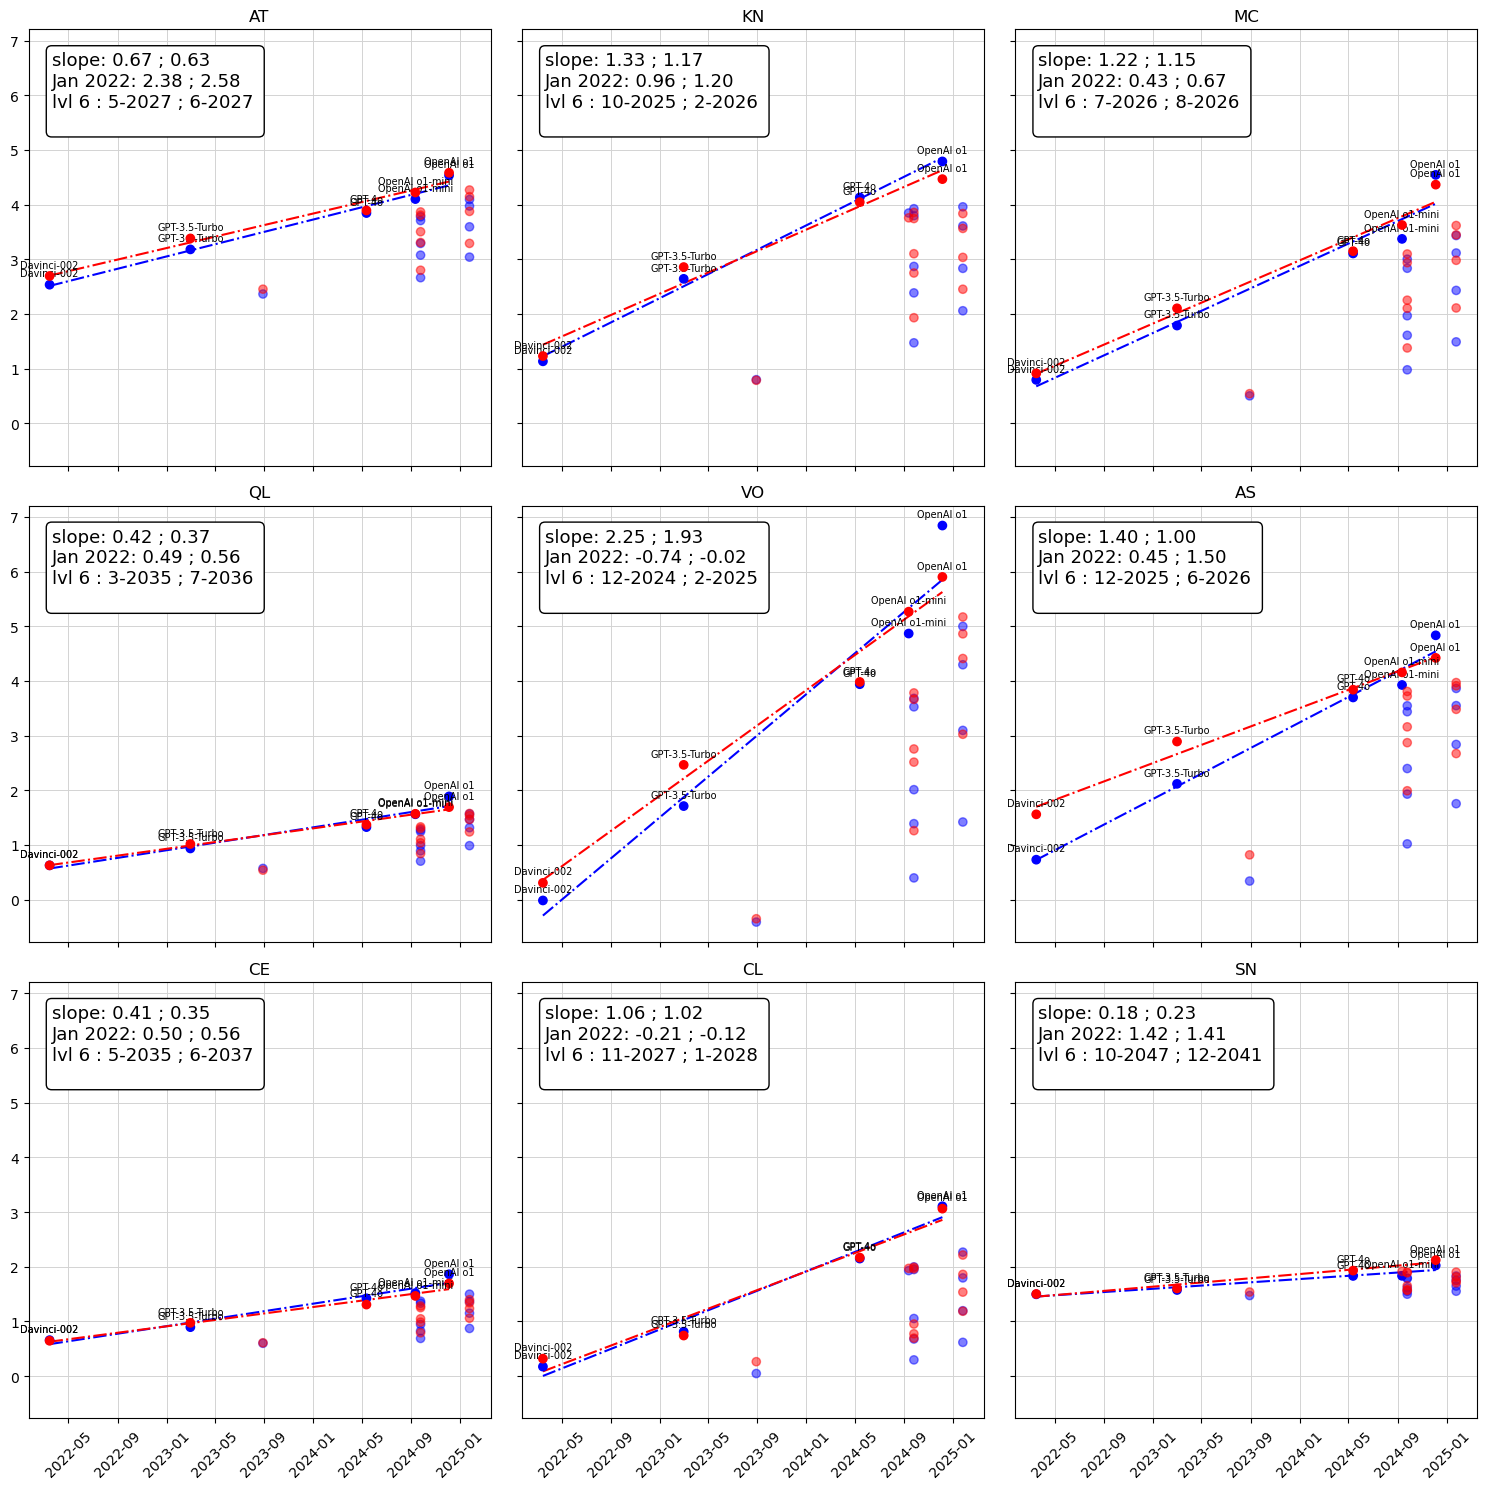

In [11]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
demand_groups = list(rescaled_profiles_filtered_df.columns)
demand_groups.remove('Date')
release_dates = rescaled_profiles_filtered_df['Date'].values
model_names = list(rescaled_profiles_filtered_df.index)
xs = release_dates

for i in range(3):
    for j in range(3):
        ax = axs[i][j]
        ys = rescaled_profiles_unfiltered_df[demand_groups[3*i+j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(1)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else : alphas.append(0.5)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25) for x in xsfront]

        ax.scatter(xs, ys, zorder=3, c='b', alpha=alphas)

        # Labels frontière
        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_unfiltered, intercept_unfiltered, r_unfiltered, p_value_unfiltered, slope_stderr_unfiltered = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25), (max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25)
        y_0, y_1 = intercept_unfiltered + slope_unfiltered * x_0, intercept_unfiltered + slope_unfiltered * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='b')

        ax = axs[i][j]
        ys = rescaled_profiles_filtered_df[demand_groups[3*i+j]].values
        front = set(frontier_indices(xs, ys))
        alphas, xsfront, ysfront = [], [], []
        for k in range(len(xs)):
            if k in front:
                alphas.append(1)
                xsfront.append(xs[k])
                ysfront.append(ys[k])
            else : alphas.append(0.5)
        xsfront_years_since_2022 = [(x - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25) for x in xsfront]

        ax.scatter(xs, ys, zorder=3, c='r', alpha=alphas)

        # Labels frontière
        for k in front:
            ax.annotate(
                model_names[k], (xs[k], ys[k]),
                textcoords="offset points", xytext=(0, 6),
                ha='center', fontsize=7
            )

        regression = stats.linregress(xsfront_years_since_2022, ysfront, alternative='greater')
        slope_filtered, intercept_filtered, r_filtered, p_value_filtered, slope_stderr_filtered = regression
        intercept_stderr = regression.intercept_stderr
        x_0, x_1 = (min(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25), (max(xsfront) - pd.to_datetime("2022-01-01")).total_seconds()/(3600*24*365.25)
        y_0, y_1 = intercept_filtered + slope_filtered * x_0, intercept_filtered + slope_filtered * x_1
        ax.plot([min(xsfront), max(xsfront)], [y_0, y_1], ls='dashdot', color='r')

        x_millionth_unfiltered = (6-intercept_unfiltered)/slope_unfiltered
        date_millionth_unfiltered = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_unfiltered*365.25, unit='D')
        x_millionth_filtered = (6-intercept_filtered)/slope_filtered
        date_millionth_filtered = pd.to_datetime("2022-01-01") + pd.to_timedelta(x_millionth_filtered*365.25, unit='D')

        stats_text = (
        f"slope: {slope_unfiltered:.2f} ; {slope_filtered:.2f} \n"
        f"Jan 2022: {intercept_unfiltered:.2f} ; {intercept_filtered:.2f}\n"
        f"lvl 6 : {date_millionth_unfiltered.month}-{date_millionth_unfiltered.year} ; {date_millionth_filtered.month}-{date_millionth_filtered.year} \n"
        )

        # Attention : les cas où la pente est nulle ou strictement négative ne sont pas gérés ici, et donneraient respectivement une erreur ou un résultat qu'il faut interpréter différemment du cas où la pente est positive. De même, le cas où la pente est inférieure à son incertitude-type pose problème.

        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=13,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='w', alpha=1),
        color='black')

        ax.set_title(demand_groups[3*i+j])

        # Grille gris clair
        ax.grid(True, color='lightgrey', linewidth=0.7, zorder=0)
        ax.set_axisbelow(True)

        # Rotation xticks
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()